# 📊 Análisis de Calidad de Alimentos

## 📌 Problema de negocio

Una empresa de distribución alimentaria ha detectado incidencias en la calidad de sus productos.  
El objetivo es identificar patrones de riesgo relacionados con temperatura y manipulación para reducir pérdidas y mejorar la seguridad alimentaria.

---

## 🎯 Objetivo

- Analizar incidencias por producto  
- Evaluar riesgos asociados a temperatura  
- Detectar patrones operativos  
- Proponer acciones correctivas basadas en datos  

## 1. 📂 Carga de datos

In [2]:
import pandas as pd

df = pd.read_csv("../data/calidad_alimentos.csv", sep=";")
df.head()

,Fecha,Producto,Temperatura,Lote,Incidencia,Tipo_Problema
0,1/01/2025,Pescado,-2,L001,No,Ninguno
1,1/01/2025,Carne,5,L002,Si,Temperatura alta
2,2/01/2025,Pescado,-1,L003,No,Ninguno
3,2/01/2025,Pollo,8,L004,Si,Temperatura alta
4,3/01/2025,Pescado,-3,L005,No,Ninguno


## 2. 🧹 Limpieza de datos

### 2.1. 🧹 Exploracion inicial

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Fecha          10 non-null     str  
 1   Producto       10 non-null     str  
 2   Temperatura    10 non-null     int64
 3   Lote           10 non-null     str  
 4   Incidencia     10 non-null     str  
 5   Tipo_Problema  10 non-null     str  
dtypes: int64(1), str(5)
memory usage: 612.0 bytes


In [3]:
df.isnull().sum()

Fecha            0
Producto         0
Temperatura      0
Lote             0
Incidencia       0
Tipo_Problema    0
dtype: int64

In [12]:
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True)

## 3. 📊 Análisis general de incidencias 

### 3.1. Incidencias 

In [5]:
df["Incidencia"].value_counts()

Incidencia
No    5
Si    5
Name: count, dtype: int64

### 3.2. Tipo de Problema 

In [6]:
df["Tipo_Problema"].value_counts()

Tipo_Problema
Ninguno             5
Temperatura alta    4
Contaminacion       1
Name: count, dtype: int64

### 3.3. Producto

In [8]:
df["Producto"].value_counts()

Producto
Pescado    4
Carne      3
Pollo      3
Name: count, dtype: int64

In [31]:
(df["Producto"].value_counts(normalize=True) * 100). round(2)

Producto
Pescado    40.0
Carne      30.0
Pollo      30.0
Name: proportion, dtype: float64

### 3.4. Temperatura

In [12]:
df["Temperatura"].value_counts()

Temperatura
-2    1
 5    1
-1    1
 8    1
-3    1
 6    1
 2    1
 4    1
 3    1
 7    1
Name: count, dtype: int64

In [13]:
df["Temperatura"].mean()

np.float64(2.9)

## 4.🔗 Relación entre producto y tipo de problema

In [14]:
df.groupby("Producto")["Tipo_Problema"].value_counts()

Producto  Tipo_Problema   
Carne     Temperatura alta    1
          Contaminacion       1
          Ninguno             1
Pescado   Ninguno             3
          Temperatura alta    1
Pollo     Temperatura alta    2
          Ninguno             1
Name: count, dtype: int64

In [10]:
pd.crosstab(df["Producto"], df["Tipo_Problema"])

Tipo_Problema,Contaminacion,Ninguno,Temperatura alta
Producto,,,
Carne,1,1,1
Pescado,0,3,1
Pollo,0,1,2


## 5. 📅 Análisis por fecha

### 5.1. 📅 Análisis por fecha

In [16]:
df.groupby("Fecha")["Incidencia"].count()


Fecha
1/01/2025    2
2/01/2025    2
3/01/2025    2
4/01/2025    2
5/01/2025    2
Name: Incidencia, dtype: int64

<Axes: xlabel='Fecha'>

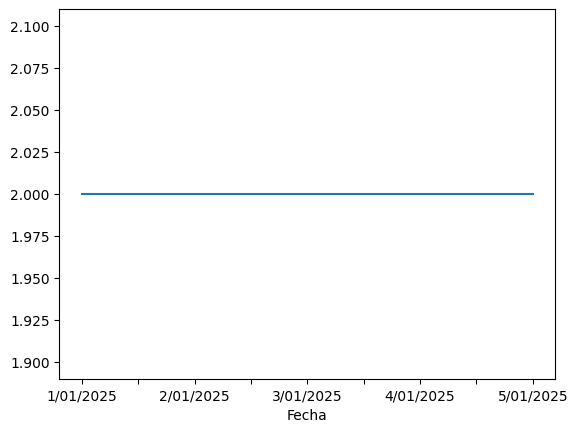

In [17]:
df.groupby("Fecha")["Incidencia"].count().plot(kind="line")

In [20]:
df.groupby(["Fecha", "Producto"])["Incidencia"].count()

Fecha      Producto
1/01/2025  Carne       1
           Pescado     1
2/01/2025  Pescado     1
           Pollo       1
3/01/2025  Carne       1
           Pescado     1
4/01/2025  Pescado     1
           Pollo       1
5/01/2025  Carne       1
           Pollo       1
Name: Incidencia, dtype: int64

In [21]:
df.groupby(["Fecha", "Tipo_Problema"])["Incidencia"].count()

Fecha      Tipo_Problema   
1/01/2025  Ninguno             1
           Temperatura alta    1
2/01/2025  Ninguno             1
           Temperatura alta    1
3/01/2025  Contaminacion       1
           Ninguno             1
4/01/2025  Ninguno             1
           Temperatura alta    1
5/01/2025  Ninguno             1
           Temperatura alta    1
Name: Incidencia, dtype: int64

## 6. 🌡️ Análisis de temperatura por producto

In [22]:
df.groupby("Producto")["Temperatura"].mean()

Producto
Carne      4.666667
Pescado   -0.500000
Pollo      5.666667
Name: Temperatura, dtype: float64

## 7. 🔥 Análisis de riesgo por temperatura

In [23]:
def alerta_temp(row):
    if row["Producto"] == "Pescado" and row["Temperatura"] > 4:
        return "Fuera de rango"
    elif row["Producto"] in ["Carne", "Pollo"] and row["Temperatura"] > 4:
        return "Fuera de rango"
    else:
        return "Ok"
df["Estado_Temperatura"] = df.apply(alerta_temp, axis=1)


In [24]:
df["Estado_Temperatura"].value_counts()

Estado_Temperatura
Ok                6
Fuera de rango    4
Name: count, dtype: int64

In [25]:
pd.crosstab(df["Producto"], df["Estado_Temperatura"])

Estado_Temperatura,Fuera de rango,Ok
Producto,,
Carne,2,1
Pescado,0,4
Pollo,2,1


## 8. 📈 Visualización

### 8.1. Problemas por tipo de producto 

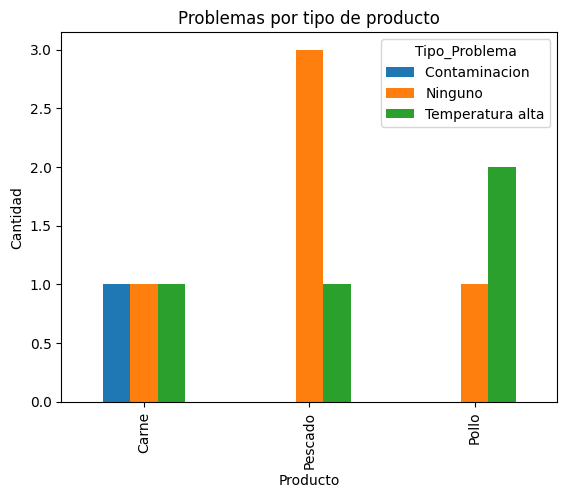

In [26]:
import matplotlib.pyplot as plt

pd.crosstab(df["Producto"], df["Tipo_Problema"]).plot(kind="bar")
plt.title("Problemas por tipo de producto")
plt.xlabel("Producto")
plt.ylabel("Cantidad")
plt.show()

### 8.2. Incidencias por producto

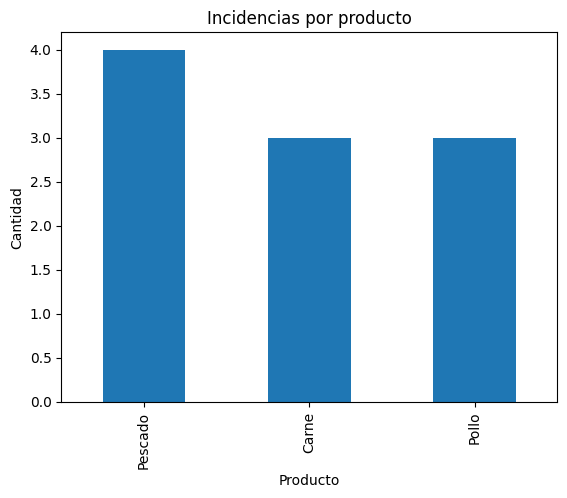

In [33]:
df["Producto"].value_counts().plot(kind="bar")
plt.title("Incidencias por producto")
plt.xlabel("Producto")
plt.ylabel("Cantidad")
plt.show()

### 8.3. Estado de temperatura por producto

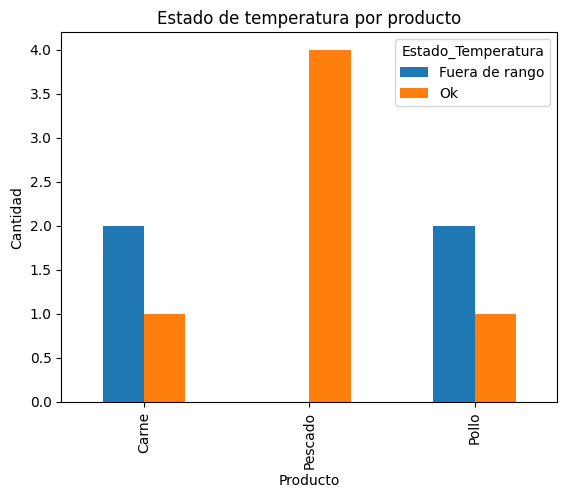

In [32]:
pd.crosstab(df["Producto"], df["Estado_Temperatura"]).plot(kind="bar")
plt.title("Estado de temperatura por producto")
plt.xlabel("Producto")
plt.ylabel("Cantidad")
plt.show()

## 9. 💡 Insights clave

- Las incidencias se presentan de forma constante a lo largo del tiempo, lo que indica fallos estructurales en los procesos operativos y no eventos aislados.
- El pescado, aunque dentro de los límites de temperatura, muestra inestabilidad térmica, lo que representa un riesgo potencial.
- La carne combina problemas de temperatura y contaminación, posicionándose como el producto de mayor riesgo sanitario.
- El pollo presenta un patrón creciente de incidencias, lo que sugiere posibles fallos en almacenamiento progresivo.

## 10. 📊 Conclusión general

- El análisis evidencia que los problemas no son puntuales, sino sistemáticos.  
Se identifican fallos tanto en el control de temperatura como en los procesos de manipulación.
- Priorizar el control en carne, estabilizar la cadena de frío en pescado y monitorear el deterioro progresivo en pollo son acciones clave para mejorar la calidad y seguridad del producto.

## 11. ✅ Recomendaciones

- Implementar alertas automáticas de temperatura  
- Analizar tiempos de almacenamiento por lote  
- Integrar datos de transporte para evaluar cadena de frío  